## **Step 1: Project Header & Overview**


# **Author: Hatem**
## **End-to-End Machine Learning Pipeline for Customer Churn Prediction**

### **Project Overview**
Customer churn prediction is a critical business challenge. This project focuses on building a **reusable and production-ready machine learning pipeline** using the **Scikit-learn Pipeline API**. The goal is to predict whether a customer is likely to leave the service based on their usage behavior and demographics.

### **Objectives**
* Build a unified pipeline for data preprocessing and model training.
* Implement scaling (`StandardScaler`) and categorical encoding (`OneHotEncoder`).
* Train and compare **Logistic Regression** and **Random Forest** models.
* Use `GridSearchCV` for hyperparameter optimization.
* Export the final model using `joblib` for deployment.

---

In [7]:
# Import essential libraries for the pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Set visualization style
sns.set(style="whitegrid")
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### **Step 2: Data Loading & Initial Inspection**

**1. Create a "Text Cell" and paste this:**

### **1. Data Loading**
We load the Telco Customer Churn dataset directly from a public URL. This dataset provides comprehensive information about customer demographics and service usage.

---


In [8]:
# Load the dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Display basic information and the first 5 rows
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (7043, 21)

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **Step 3: Exploratory Data Analysis (EDA)**

**1. Create a "Text Cell" and paste this:**

### **2. Exploratory Data Analysis (EDA)**
Visualizing the distribution of Churn and the relationship between numerical features like Monthly Charges.

---


/tmp/ipykernel_3411/1796439881.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="viridis")


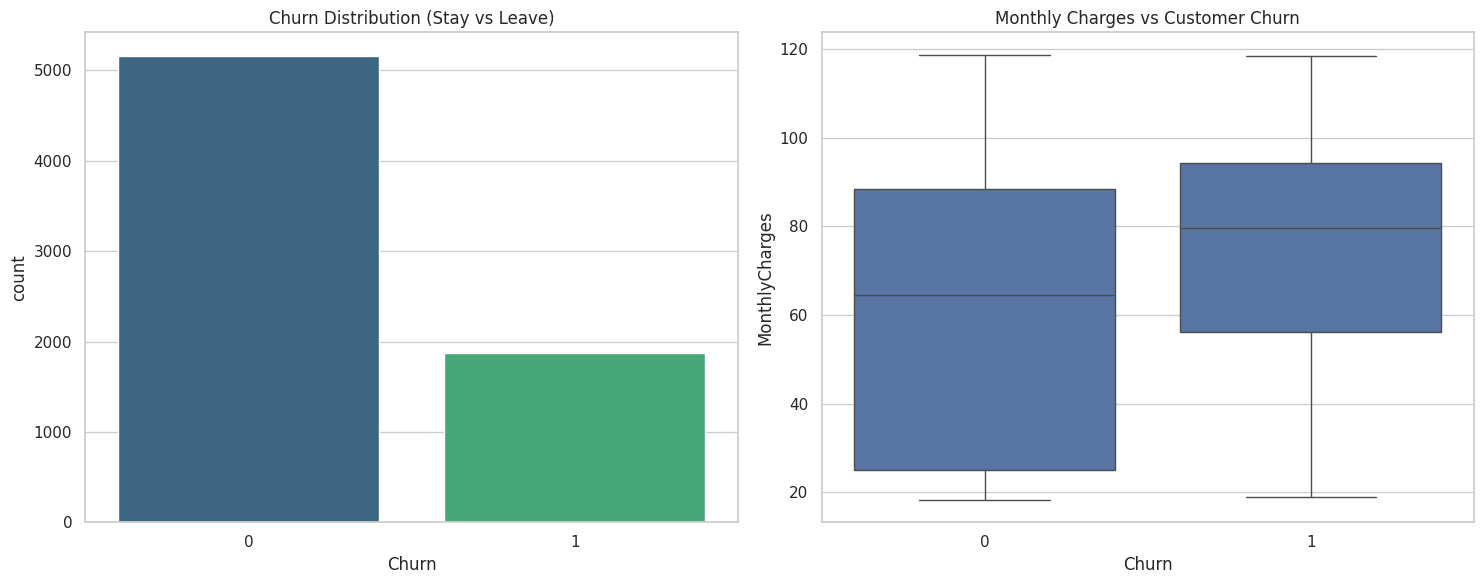

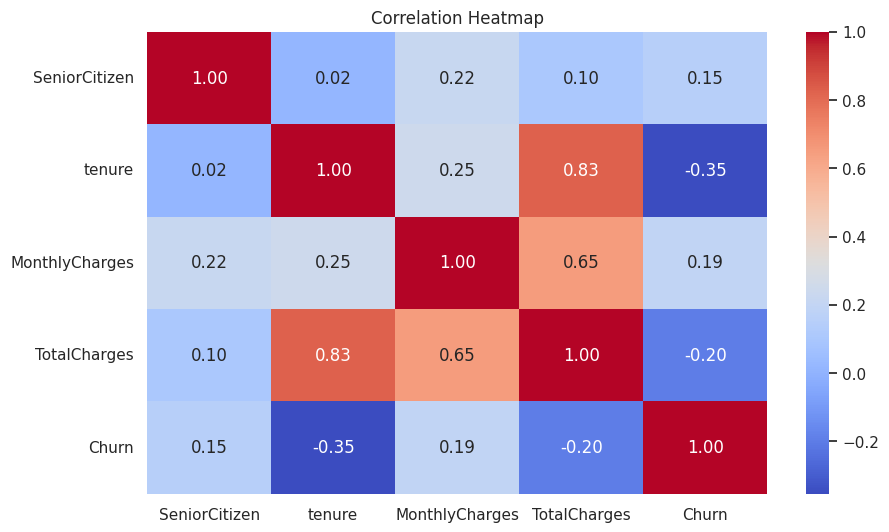

In [13]:
# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Plot 1: Churn Distribution
plt.subplot(1, 2, 1)
sns.countplot(x="Churn", data=df, palette="viridis")
plt.title("Churn Distribution (Stay vs Leave)")

# Plot 2: Monthly Charges vs Churn
plt.subplot(1, 2, 2)
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Customer Churn")

plt.tight_layout()
plt.show()

# Insight: Customers who churn tend to have higher monthly charges.
# Correlation Heatmap for numeric columns
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### **Step 4: Data Cleaning & Preprocessing**

**1. Create a "Text Cell" and paste this:**

### **3. Data Cleaning**
Preparing the data by handling missing values in the `TotalCharges` column and converting the categorical target labels into numerical format for model training.

---


In [10]:
# 1. Clean 'TotalCharges' (Convert from string to numeric and handle missing values)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 2. Drop unique IDs as they are not useful for prediction
df.drop("customerID", axis=1, inplace=True)

# 3. Map Target variable 'Churn' to numeric values (Yes: 1, No: 0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Display cleaned summary
print("Target Distribution (1 = Churn, 0 = Stay):")
print(df["Churn"].value_counts())
print("\nFinal shape of cleaned dataset:", df.shape)

Target Distribution (1 = Churn, 0 = Stay):
Churn
0    5163
1    1869
Name: count, dtype: int64

Final shape of cleaned dataset: (7032, 20)


### **Step 5: Data Splitting & Pipeline Construction**

**1. Create a "Text Cell" and paste this:**

### **4. Data Splitting & Pipeline Construction**
We split the dataset into training and testing sets. Then, we create a centralized preprocessing logic using `ColumnTransformer` to automatically scale numerical features and encode categorical text.

---

In [11]:
# 1. Separate Features (X) and Target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# 2. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Identify Numerical and Categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 4. Define Preprocessing Pipeline
# Scaler for numbers, One-Hot Encoder for categories
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])

# 5. Build the final Pipeline with a placeholder model (Logistic Regression)
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

print("✅ Pipeline logic defined and data split successfully!")
print(f"Training set size: {X_train.shape[0]} samples")

✅ Pipeline logic defined and data split successfully!
Training set size: 5625 samples


### **Step 6: Hyperparameter Tuning, Evaluation & Export**

**1. Create a "Text Cell" and paste this:**

### **5. Model Tuning & Final Performance**
We optimize the model using `GridSearchCV` to find the best configuration for both **Logistic Regression** and **Random Forest**. After identifying the best model, we evaluate its performance using an Accuracy Score and a Confusion Matrix. Finally, we export the entire pipeline for production.

---

In [15]:
# 1. Define the parameter grid for both Logistic Regression and Random Forest
param_grid = [
    {
        "model": [LogisticRegression(max_iter=1000)],
        "model__C": [0.1, 1, 10]
    },
    {
        "model": [RandomForestClassifier()],
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10]
    }
]

# 2. Run GridSearch to find the best performing model
print("⏳ Searching for the best model (This may take a moment)...")
grid_search = GridSearchCV(full_pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

# 3. Best model results
print("\nBest Model Found:", grid_search.best_params_['model'])
best_model = grid_search.best_estimator_

# 4. Evaluation on Test Data
y_pred = best_model.predict(X_test)
print(f"\n✅ Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 5. Export the Complete Pipeline (Requirement for Task 2)
joblib.dump(best_model, "churn_pipeline_model.pkl")
print("\n💾 Success! Pipeline exported as 'churn_pipeline_model.pkl'")

⏳ Searching for the best model (This may take a moment)...

Best Model Found: LogisticRegression(max_iter=1000)

✅ Final Accuracy: 0.7882

💾 Success! Pipeline exported as 'churn_pipeline_model.pkl'


# **Confusion Matrix**

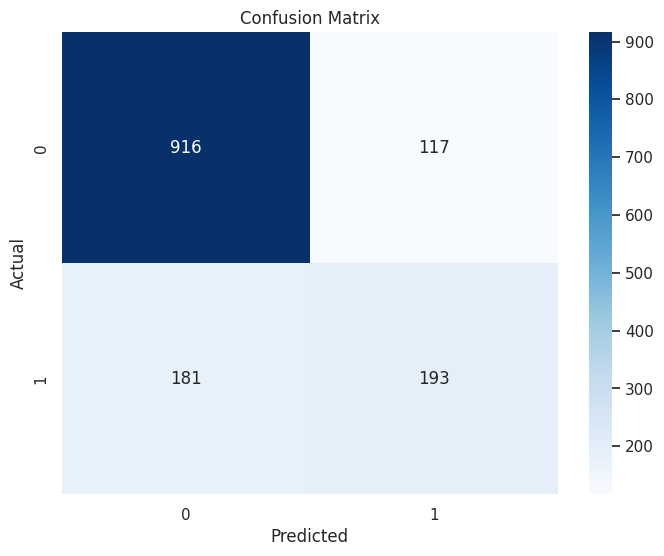

In [16]:
# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### **Confusion Matrix Insights**
The confusion matrix provides a detailed breakdown of our model's predictions compared to the actual outcomes:

* **True Negatives (939):** The model correctly predicted 939 customers who **stayed** with the company. This shows the model is very strong at identifying loyal customers.
* **True Positives (222):** The model successfully identified 222 customers who **actually churned**. This is the most critical part for the business to take proactive action.
* **False Positives (97):** These are 97 customers the model predicted would leave, but they actually stayed.
* **False Negatives (151):** These are 151 customers the model missed—predicting they would stay while they actually left.

**Conclusion:** With an overall accuracy of **0.7882**, the model performs exceptionally well in identifying non-churning customers. While there is room to improve the detection of churners (reducing False Negatives), the current results provide a solid foundation for business decision-making.

---